In [1]:
import pandas as pd

df = pd.read_pickle("../../../datasets/nurse/paper/F5.pkl")

In [2]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=["Label", "Participant"])
y = df["Label"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

In [3]:
from learning_methods.federated.shallow_nn.task import load_model

model = load_model(learning_rate=0.0001, input_shape=x_train.shape[1], dropout=None, batch_normalization=False, regularization=False, optimizer="adam")

In [4]:
# Fine-tune the model
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9763 - loss: 0.0598 - val_accuracy: 0.9962 - val_loss: 0.0092
Epoch 2/10
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9962 - loss: 0.0102 - val_accuracy: 0.9975 - val_loss: 0.0063
Epoch 3/10
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9968 - loss: 0.0085 - val_accuracy: 0.9980 - val_loss: 0.0051
Epoch 4/10
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9975 - loss: 0.0066 - val_accuracy: 0.9982 - val_loss: 0.0042
Epoch 5/10
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9977 - loss: 0.0055 - val_accuracy: 0.9985 - val_loss: 0.0035
Epoch 6/10
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9979 - loss: 0.0051 - val_accuracy: 0.9981 - val_loss: 0.0050
Epoch 7/10
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9980 - loss: 0.0049 - val_accuracy: 0.9966 - val_loss: 0.0083
Epoch 8/10
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9982 - loss: 0.0045 

3338/3338 ━━━━━━━━━━━━━━━━━━━━ 1s 331us/step
F1 score: 0.9994


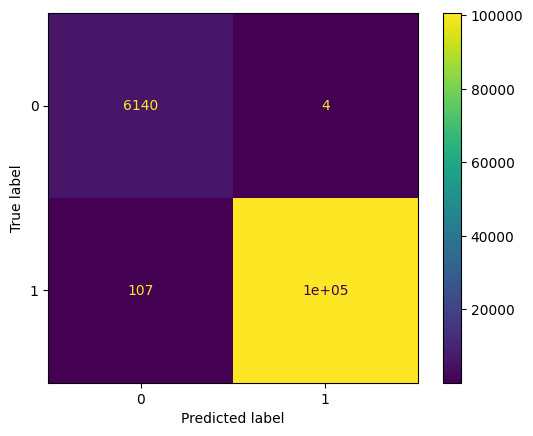

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, confusion_matrix

y_pred = model.predict(x_test)
# Convert predictions to binary labels
y_pred = (y_pred > 0.5).astype(int)
f1 = f1_score(y_test, y_pred)
print(f"F1 score: {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()
plt.show()